### E. RunnableBranch
- Purpose: To create conditional workflows. It's like an "if-else"
statement for your chains. Based on a condition, it routes the execution
to one of several runnables.
- When to Use: When the next step in your pipeline depends on the
result of a previous step (e.g., classify an email and then handle it
differently based on its category).

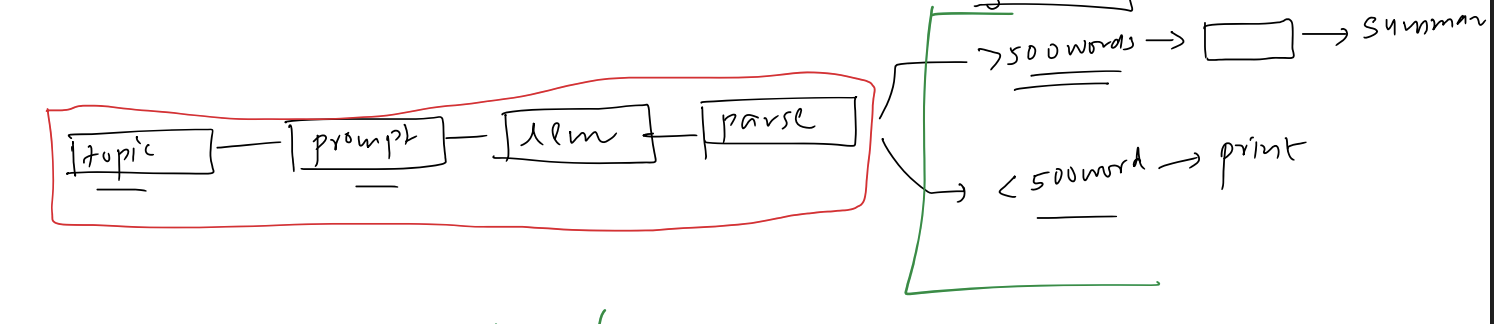

### Code Example (Scenario: Generate a report; summarize if > 300 words, else return as is):

### define model and parser

In [1]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
import os

# Load environment variables
load_dotenv()

api_key = os.getenv("Hugging_face_api_token")

# Create LLM endpoint
llm = HuggingFaceEndpoint(
    # repo_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="text-generation",
    huggingfacehub_api_token=api_key,
)

# Wrap with chat interface
model = ChatHuggingFace(llm=llm)

In [2]:
from langchain_core.output_parsers import StrOutputParser
parser=StrOutputParser()

### define prompt template

In [3]:
from langchain_core.prompts import PromptTemplate
# generate report prompt
report_gen_prompt=PromptTemplate(
    template="Write a detailed report on {topic}",
    input_variables=["topic"]
)
# summarize report prompt
summarize_prompt=PromptTemplate(
    template="Summarize this report: \n {text} ",
    input_variables=["text"]
)

### define chain and invoke

In [4]:
# chain 1: generate report
from langchain_core.runnables import RunnableBranch, RunnablePassthrough


report_gen_chain=report_gen_prompt|model|parser
#chain 2:Branch chain (summarize chain or pass through)based on condition
summarize_chain=summarize_prompt|model|parser

# define the branch conditions
branch=RunnableBranch(
    # (condition 1,run this chain1/runnable)
    # (condition2,run this chain2/runnable)
    # default condition

    # Condition 1: If text length > 300 words, run summarize_chain
    (lambda x:len(x.split())>300,summarize_chain),
    # Default: Otherwise, just pass the text through
    RunnablePassthrough()
)

# Final Chain:Generate Report -> Branch(summarize or passthrough)
final_chain=report_gen_chain |branch


In [ ]:
result=final_chain.invoke({
    "topic":"Russia-Ukraine conflict"
})

In [6]:
print(result)

between Russia and Ukraine, with Ukraine seeking closer ties to Europe. The conflict has had economic consequences for both countries, as well as for Europe and Russia's relations with Europe. It has also led to an increase in military spending and a heightened security presence in Eastern Europe.

Additionally, the conflict has had humanitarian consequences, with thousands of deaths and the displacement of over a million people. It has also led to a refugee crisis, with many Ukrainians fleeing to neighboring countries.

The conflict has also had implications for international law and norms, particularly with regards to territorial integrity and sovereignty. It has highlighted the challenges of resolving conflicts in the post-Cold War era, and the limitations of diplomatic and economic sanctions in changing Russian behavior.

Overall, the Russia-Ukraine conflict is a complex issue with deep historical roots and significant geopolitical implications. It remains an ongoing concern for th

In [7]:
print(type(result))

<class 'langchain_core.messages.base.TextAccessor'>


In [11]:
len(result.split())

164

In [10]:
result1=final_chain.invoke({
    "topic":"Russia-Ukraine conflict in 400 words"
})

In [12]:
print(result1)

The Russia-Ukraine conflict is an ongoing political and military crisis that started in 2014, primarily in Eastern Ukraine's Donetsk and Luhansk regions. The causes of the conflict are rooted in Ukraine's history, geopolitical realities, and complex relations with Russia. The conflict escalated when Ukraine's then-president, Viktor Yanukovych, withdrew from an agreement to deepen ties with the European Union and instead aligned with Russia. In response, protests erupted, leading to Yanukovych's ousting in February 2014.

Shortly after, Russia annexed Crimea, causing separatist movements to emerge in Eastern Ukraine. Pro-Russian separatists declared independence from Ukraine, forming the self-proclaimed Donetsk People's Republic (DPR) and Luhansk People's Republic (LPR). The Ukrainian military and separatist forces have been engaged in a brutal conflict since, resulting in over a million displaced people, extensive damage to infrastructure, and numerous human rights violations. Both sid

In [14]:
len(result1.split())

230